In [1]:

import os 
import sys
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

sys.path.append("../")
PATH = "../../"

# No feature selection - all 15 variables

In [2]:
''' 
Prepare data --> change here for different setups!
'''

### Manually selected vars
varFolder = "manual_selection"
var = f"allVars_mgfaRecoded"  

''' 
Read data
'''
metrics = ["precision",
            "recall",
            "f1",
            "accuracy",
            "model",
            "auc",
            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

## Table + calculate CI

In [3]:
# confidence intervals
alpha = 0.95

In [4]:
dic_CI = dict()
for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
df_CI.to_csv(f"{PATH_res}/CI_performances.csv")

df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,69.957709,68.230222,70.556546,67.915231,74.107301,76.961172
mean,73.092622,74.154341,73.533711,70.137836,76.493026,79.881038
upper CI,76.242922,80.485494,76.161300,72.003790,79.065731,82.735844


(0.5, 1.0)

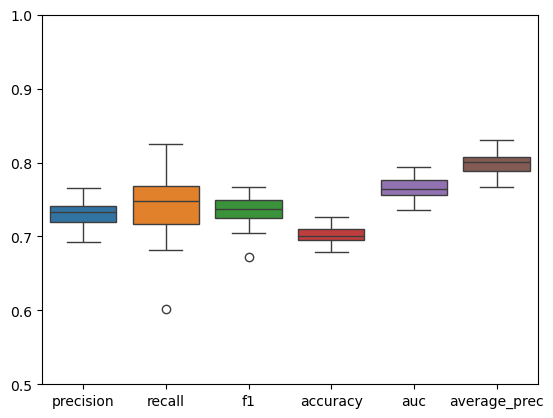

In [5]:
fig, ax = plt.subplots()

df_15 = df.copy()
df_15["vars"] = "manual"
sns.boxplot(data=df_15)
ax.set_ylim(0.5, 1)

# Feature selection - 5 variables 

In [6]:
''' 
Prepare data --> change here for different setups!
'''

### Feature selected vars
target="gender"
percentBoruta = 100
varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"

''' 
Read data
'''
metrics = ["precision",
                            "recall",
                            "f1",
                            "accuracy",
                            "model",
                            "auc",
                            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

## Table

In [7]:
# confidence intervals
alpha = 0.95

In [8]:
dic_CI = dict()
for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
df_CI.to_csv(f"{PATH_res}/CI_performances.csv")

df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,62.184332,66.552017,66.518393,60.666782,65.118450,70.379243
mean,68.373620,74.098613,70.995959,66.045963,71.270589,75.265804
upper CI,73.202916,82.020489,73.590057,69.588215,75.053761,79.149334


(0.5, 1.0)

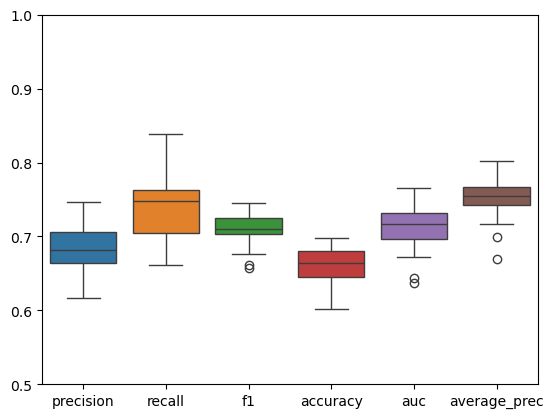

In [9]:
fig, ax = plt.subplots()

df_5 = df.copy()
df_5["vars"] = "fs"

sns.boxplot(data=df_5)
ax.set_ylim(0.5, 1)

## Combined plot

In [12]:
df_comb = pd.concat([df_15, df_5], axis=0, ignore_index=True)
df_comb

,precision,recall,f1,accuracy,auc,average_prec,vars
0,0.762670,0.736277,0.749241,0.715369,0.777441,0.819416,manual
1,0.714620,0.757125,0.735259,0.696761,0.762095,0.788826,manual
2,0.718547,0.691635,0.704835,0.680221,0.750070,0.788691,manual
3,0.740891,0.693182,0.716243,0.700207,0.765314,0.788216,manual
4,0.732491,0.755030,0.743590,0.696761,0.750651,0.798862,manual
...,...,...,...,...,...,...,...
97,0.659375,0.771011,0.710837,0.645072,0.686962,0.743164,fs
98,0.681128,0.773399,0.724337,0.670572,0.716968,0.745132,fs
99,0.656383,0.761728,0.705143,0.644383,0.707292,0.755686,fs
100,0.714110,0.706311,0.710189,0.672640,0.722805,0.766857,fs


<Axes: xlabel='variable', ylabel='value'>

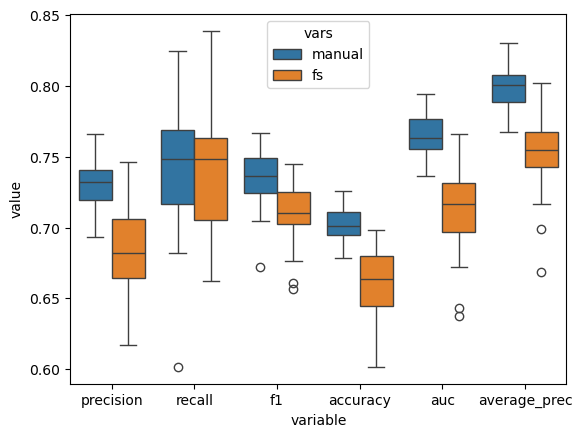

In [15]:
a = df_comb.melt(["vars"])
sns.boxplot(data=a, x= "variable", y="value", hue="vars")

TtestResult(statistic=12.570353459123048, pvalue=2.645622292117183e-22, df=100.0)

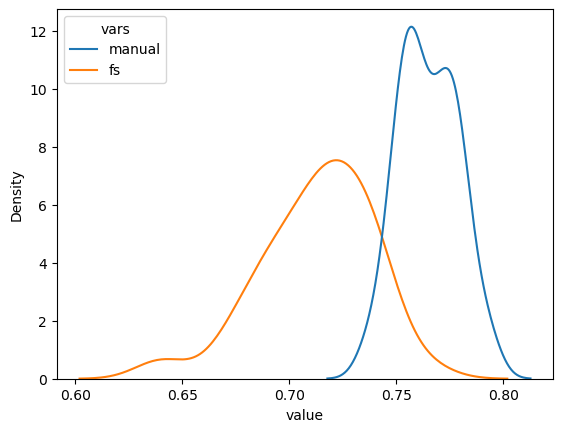

In [16]:
from scipy.stats import ttest_ind

a = df_comb.loc[:,["auc", "vars"]].melt(["vars"])
sns.kdeplot(data=a, x="value", hue="vars")


ttest_ind(df_15["auc"], df_5["auc"])